<a href="https://colab.research.google.com/github/JaimeB252019/PARCIAL4-BELLOSO-PALACIOS-JAIME-DANEL2520192019/blob/main/Ejer02EV04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTAR LIBRERIAS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Ocultar warnings
warnings.filterwarnings("ignore")

1. CARGA DE ARCHIVO

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/JaimeB252019/PARCIAL4-BELLOSO-PALACIOS-JAIME-DANEL2520192019/refs/heads/main/Archivos/clave_C_correlacion.csv', delimiter=',')

print("Dataset cargado correctamente")

Dataset cargado correctamente


2. IDENTIFICAR LAS VARIABLES NUMÉRICAS DEL DATASET.

In [6]:
numericas = df.select_dtypes(include=np.number)

print(numericas.columns)


Index(['edad', 'ingresos_mensuales', 'frecuencia_compra', 'ticket_promedio',
       'satisfaccion', 'reclamos', 'uso_app', 'tiempo_respuesta',
       'consumo_total'],
      dtype='object')


3. REVISAR DATOS NULOS, VALORES ATÍPICOS Y CONSISTENCIA GENERAL.

In [7]:
# Valores nulos
print(df.isnull().sum())

# Duplicados
print("Duplicados:", df.duplicated().sum())

# Valores atípicos
for columna in numericas.columns:

    Q1 = numericas[columna].quantile(0.25)
    Q3 = numericas[columna].quantile(0.75)

    IQR = Q3 - Q1

    inferior = Q1 - 1.5 * IQR
    superior = Q3 + 1.5 * IQR

    atipicos = numericas[
        (numericas[columna] < inferior) |
        (numericas[columna] > superior)
    ]

    print(columna, ":", len(atipicos), "valores atípicos")

cliente_id            0
edad                  0
ingresos_mensuales    0
frecuencia_compra     0
ticket_promedio       1
satisfaccion          1
reclamos              0
uso_app               0
tiempo_respuesta      1
consumo_total         0
dtype: int64
Duplicados: 1
edad : 0 valores atípicos
ingresos_mensuales : 0 valores atípicos
frecuencia_compra : 10 valores atípicos
ticket_promedio : 0 valores atípicos
satisfaccion : 4 valores atípicos
reclamos : 3 valores atípicos
uso_app : 6 valores atípicos
tiempo_respuesta : 1 valores atípicos
consumo_total : 8 valores atípicos


4. CALCULAR LA MATRIZ DE CORRELACIÓN.

In [8]:
correlacion = numericas.corr()

print(correlacion)

                        edad  ingresos_mensuales  frecuencia_compra  \
edad                1.000000           -0.022816           0.020426   
ingresos_mensuales -0.022816            1.000000           0.216606   
frecuencia_compra   0.020426            0.216606           1.000000   
ticket_promedio     0.130254            0.625489           0.133248   
satisfaccion        0.038807            0.096343           0.184660   
reclamos            0.013808           -0.011610          -0.046948   
uso_app            -0.010488            0.137213           0.349597   
tiempo_respuesta   -0.015517           -0.073670          -0.127446   
consumo_total       0.081122            0.514002           0.825424   

                    ticket_promedio  satisfaccion  reclamos   uso_app  \
edad                       0.130254      0.038807  0.013808 -0.010488   
ingresos_mensuales         0.625489      0.096343 -0.011610  0.137213   
frecuencia_compra          0.133248      0.184660 -0.046948  0.349597 

5. CREAR UN MAPA DE CALOR O GRÁFICO DE CORRELACIÓN.

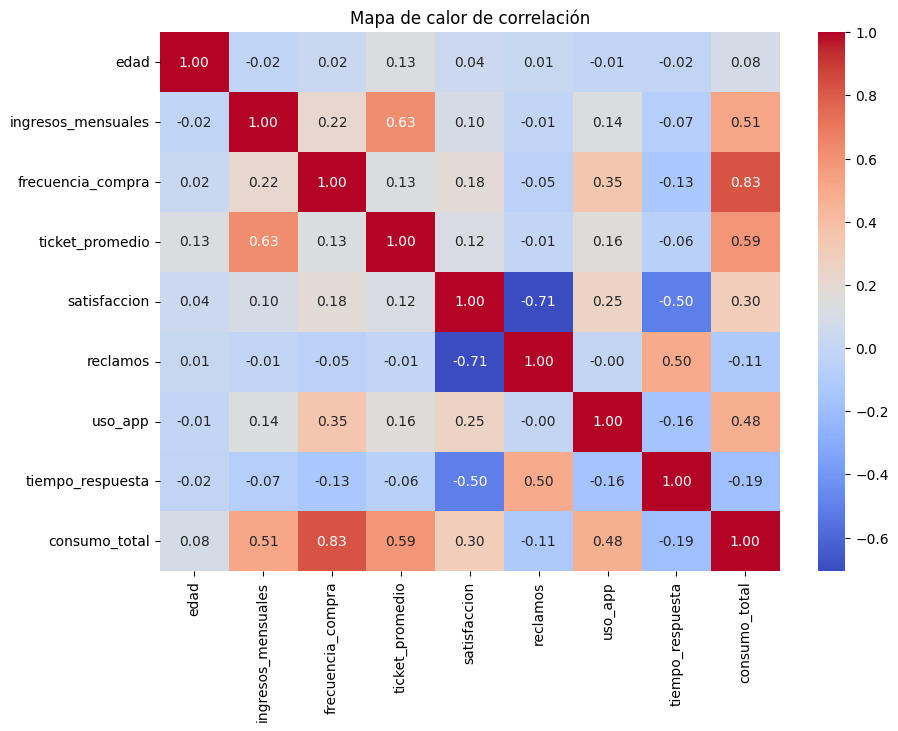

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,7))

sns.heatmap(
    correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Mapa de calor de correlación")

plt.show()

6. IDENTIFICAR LAS CORRELACIONES POSITIVAS MÁS IMPORTANTES.

In [10]:
corr_pos = correlacion.unstack()

corr_pos = corr_pos.sort_values(ascending=False)

corr_pos = corr_pos[corr_pos < 1]

print(corr_pos.head(10))

frecuencia_compra   consumo_total         0.825424
consumo_total       frecuencia_compra     0.825424
ticket_promedio     ingresos_mensuales    0.625489
ingresos_mensuales  ticket_promedio       0.625489
ticket_promedio     consumo_total         0.591713
consumo_total       ticket_promedio       0.591713
                    ingresos_mensuales    0.514002
ingresos_mensuales  consumo_total         0.514002
reclamos            tiempo_respuesta      0.495393
tiempo_respuesta    reclamos              0.495393
dtype: float64


7. IDENTIFICAR LAS CORRELACIONES NEGATIVAS MÁS IMPORTANTES.

In [11]:
corr_neg = correlacion.unstack()

corr_neg = corr_neg.sort_values()

print(corr_neg.head(10))

reclamos           satisfaccion        -0.706681
satisfaccion       reclamos            -0.706681
                   tiempo_respuesta    -0.503321
tiempo_respuesta   satisfaccion        -0.503321
                   consumo_total       -0.190078
consumo_total      tiempo_respuesta    -0.190078
tiempo_respuesta   uso_app             -0.161273
uso_app            tiempo_respuesta    -0.161273
frecuencia_compra  tiempo_respuesta    -0.127446
tiempo_respuesta   frecuencia_compra   -0.127446
dtype: float64


8. EXPLICAR AL MENOS 4 RELACIONES ENCONTRADAS ENTRE VARIABLES.

1. Las correlaciones positivas indican que ambas variables aumentan juntas.

2. Las correlaciones negativas muestran que cuando una variable aumenta, la otra disminuye.

3. Las relaciones cercanas a 1 representan correlaciones fuertes.

4. Las relaciones cercanas a 0 representan correlaciones débiles."

9. CONCLUIR CÓMO ESTAS RELACIONES PUEDEN AYUDAR A LA EMPRESA.

El análisis de correlación permitió identificar relaciones importantes entre las variables numéricas del dataset, mostrando cuáles factores tienen mayor influencia entre sí. A través de la matriz de correlación y el mapa de calor fue posible detectar correlaciones positivas y negativas que ayudan a comprender mejor el comportamiento de los datos.

Además, la revisión de valores nulos, duplicados y atípicos permitió validar la calidad de la información antes del análisis, asegurando resultados más confiables. Las relaciones encontradas pueden servir a la empresa para mejorar la toma de decisiones, identificar patrones relevantes y optimizar estrategias relacionadas con ventas, rendimiento o comportamiento de clientes según las variables analizadas.